# Calderon's Problem PlayGround

## Direct problem - forward finite differences solver

In [37]:
# filename: codebase/fdm_forward_solver.py
import os
import time
import numpy as np
import scipy.sparse as sp
from scipy.sparse.linalg import spsolve
import matplotlib.pyplot as plt
import matplotlib as mpl

# Set plotting style
mpl.rcParams['figure.facecolor'] = 'white'
mpl.rcParams['axes.facecolor'] = 'white'
mpl.rcParams['savefig.facecolor'] = 'white'
mpl.rcParams['text.usetex'] = False

### Generate the data

In [38]:
class FDMForwardSolver:
    """
    A Finite Difference Method (FDM) solver for the 2D Calderon's problem.

    This class solves the elliptic PDE nabla . (gamma * nabla u) = 0 on a
    square domain [0, 1] x [0, 1] with Dirichlet boundary conditions.
    """

    def __init__(self, N):
        """
        Initializes the FDM solver.

        Args:
            N (int): The number of grid points in each dimension.
        """
        self.N = N
        self.h = 1.0 / (N - 1)
        self.x = np.linspace(0, 1, N)
        self.y = np.linspace(0, 1, N)
        self.xx, self.yy = np.meshgrid(self.x, self.y)
        self.boundary_info = self.get_boundary_info()

    def get_boundary_info(self):
        """
        Identifies boundary nodes, coordinates, and normal vectors.

        Returns:
            dict: A dictionary containing:
                'indices': 1D indices of boundary nodes.
                'coords': (x, y) coordinates of boundary nodes.
                'normals': (nx, ny) normal vectors for each boundary node.
        """
        indices = []
        coords = []
        normals = []
        is_boundary = np.zeros((self.N, self.N), dtype=bool)

        for i in range(self.N):
            for j in range(self.N):
                is_bnd = False
                normal = [0, 0]
                if i == 0:  # Bottom
                    is_bnd = True
                    normal[1] = -1.0
                if i == self.N - 1:  # Top
                    is_bnd = True
                    normal[1] = 1.0
                if j == 0:  # Left
                    is_bnd = True
                    normal[0] = -1.0
                if j == self.N - 1:  # Right
                    is_bnd = True
                    normal[0] = 1.0

                if is_bnd:
                    idx_1d = i * self.N + j
                    indices.append(idx_1d)
                    coords.append((self.x[j], self.y[i]))
                    # Normalize the normal vector in case of corners
                    norm_len = np.sqrt(normal[0]**2 + normal[1]**2)
                    normals.append((normal[0]/norm_len, normal[1]/norm_len))
                    is_boundary[i, j] = True

        # Ensure unique nodes for corners
        unique_indices, unique_idx_map = np.unique(indices, return_index=True)
        
        return {
            'indices': unique_indices,
            'coords': np.array(coords)[unique_idx_map],
            'normals': np.array(normals)[unique_idx_map],
            'mask': is_boundary
        }


    def _assemble_system(self, gamma):
        """
        Assembles the sparse matrix A for the linear system Au=b.

        Args:
            gamma (np.ndarray): A N x N array of conductivity values.

        Returns:
            scipy.sparse.csc_matrix: The assembled sparse matrix A.
        """
        num_nodes = self.N * self.N
        A = sp.lil_matrix((num_nodes, num_nodes))
        h2 = self.h * self.h

        for i in range(1, self.N - 1):
            for j in range(1, self.N - 1):
                p = i * self.N + j

                # Harmonic mean for conductivity at interfaces
                gamma_E = 2 * gamma[i, j] * gamma[i, j + 1] / (gamma[i, j] + gamma[i, j + 1])
                gamma_W = 2 * gamma[i, j] * gamma[i, j - 1] / (gamma[i, j] + gamma[i, j - 1])
                gamma_N = 2 * gamma[i, j] * gamma[i + 1, j] / (gamma[i, j] + gamma[i + 1, j])
                gamma_S = 2 * gamma[i, j] * gamma[i - 1, j] / (gamma[i, j] + gamma[i - 1, j])

                A[p, p] = -(gamma_E + gamma_W + gamma_N + gamma_S) / h2
                A[p, p + 1] = gamma_E / h2  # East
                A[p, p - 1] = gamma_W / h2  # West
                A[p, p + self.N] = gamma_N / h2  # North
                A[p, p - self.N] = gamma_S / h2  # South

        return A.tocsc()

    def solve(self, gamma, boundary_values):
        """
        Solves the forward problem for a given gamma and boundary conditions.

        Args:
            gamma (np.ndarray): The N x N conductivity map.
            boundary_values (dict): A dictionary mapping 1D boundary indices
                                    to potential values.

        Returns:
            np.ndarray: A N x N array of the potential u.
        """
        num_nodes = self.N * self.N
        A = self._assemble_system(gamma)
        b = np.zeros(num_nodes)

        # Apply Dirichlet boundary conditions
        for idx, val in boundary_values.items():
            A[idx, :] = 0
            A[idx, idx] = 1
            b[idx] = val

        u_flat = spsolve(A, b)
        return u_flat.reshape((self.N, self.N))

    def compute_normal_current(self, u, gamma):
        """
        Computes the normal current density J = gamma * du/dn on the boundary.

        Args:
            u (np.ndarray): The N x N potential field.
            gamma (np.ndarray): The N x N conductivity map.

        Returns:
            np.ndarray: A 1D array of normal current densities at boundary points.
        """
        bnd_indices = self.boundary_info['indices']
        bnd_normals = self.boundary_info['normals']
        bnd_coords_map = {tuple(self.boundary_info['coords'][i]): i for i in range(len(bnd_indices))}
        
        J = np.zeros(len(bnd_indices))
        
        for i in range(self.N):
            for j in range(self.N):
                if not self.boundary_info['mask'][i, j]:
                    continue

                coord_tuple = (self.x[j], self.y[i])
                if coord_tuple not in bnd_coords_map:
                    continue
                
                map_idx = bnd_coords_map[coord_tuple]
                nx, ny = bnd_normals[map_idx]
                
                # Compute gradients using second-order one-sided differences
                du_dx = 0.0
                du_dy = 0.0

                # Gradient in x
                if j == 0:  # Left boundary, forward difference
                    du_dx = (-3 * u[i, 0] + 4 * u[i, 1] - u[i, 2]) / (2 * self.h)
                elif j == self.N - 1:  # Right boundary, backward difference
                    du_dx = (3 * u[i, -1] - 4 * u[i, -2] + u[i, -3]) / (2 * self.h)
                else: # Interior point for x-gradient (corners on y-boundary)
                    du_dx = (u[i, j + 1] - u[i, j - 1]) / (2 * self.h)

                # Gradient in y
                if i == 0:  # Bottom boundary, forward difference
                    du_dy = (-3 * u[0, j] + 4 * u[1, j] - u[2, j]) / (2 * self.h)
                elif i == self.N - 1:  # Top boundary, backward difference
                    du_dy = (3 * u[-1, j] - 4 * u[-2, j] + u[-3, j]) / (2 * self.h)
                else: # Interior point for y-gradient (corners on x-boundary)
                    du_dy = (u[i + 1, j] - u[i - 1, j]) / (2 * self.h)

                du_dn = du_dx * nx + du_dy * ny
                J[map_idx] = gamma[i, j] * du_dn
                
        return J


# def get_gamma_single_inclusion(N):
#     """Generates a conductivity map with a single circular inclusion."""
#     gamma = np.ones((N, N))
#     center_x, center_y, radius = 0.5, 0.5, 0.2
#     x = np.linspace(0, 1, N)
#     y = np.linspace(0, 1, N)
#     xx, yy = np.meshgrid(x, y)
#     mask = (xx - center_x)**2 + (yy - center_y)**2 < radius**2
#     gamma[mask] = 2.0
#     return gamma

# def get_gamma_gaussian(N):
#     """Generates a conductivity map with a 2D Gaussian inclusion."""
#     gamma = np.ones((N, N))
#     center_x, center_y, radius = 0.5, 0.5, 0.1
#     x = np.linspace(0, 1, N)
#     y = np.linspace(0, 1, N)
#     xx, yy = np.meshgrid(x, y)
    
#     sigma = radius
#     gaussian = np.exp(-((xx - center_x)**2 + (yy - center_y)**2) / (2 * sigma**2))
    
#     # Scale so that max = 2.0 (background=1, peak=2)
#     gamma += gaussian  # background 1 + bump [0..1]
    
#     return gamma

# def get_gamma_radial_sine(N, freq=5, amplitude=1.0):
#     """
#     Generates a radially symmetric conductivity map with sine variation.
    
#     Parameters
#     ----------
#     N : int
#         Grid size (N x N).
#     freq : float
#         Frequency of the sine oscillation in radial direction.
#     amplitude : float
#         Amplitude of oscillation.
#     """
#     gamma = np.ones((N, N))
#     center_x, center_y = 0.5, 0.5
    
#     x = np.linspace(0, 1, N)
#     y = np.linspace(0, 1, N)
#     xx, yy = np.meshgrid(x, y)
    
#     r = np.sqrt((xx - center_x)**2 + (yy - center_y)**2)
    
#     gamma += amplitude * np.sin(2 * np.pi * freq * r)
    
#     return gamma


# def get_gamma_multiple_inclusions(N):
#     """Generates a conductivity map with two circular inclusions."""
#     gamma = np.ones((N, N))
#     x = np.linspace(0, 1, N)
#     y = np.linspace(0, 1, N)
#     xx, yy = np.meshgrid(x, y)
#     mask1 = (xx - 0.3)**2 + (yy - 0.6)**2 < 0.15**2
#     gamma[mask1] = 2.0
#     mask2 = (xx - 0.7)**2 + (yy - 0.3)**2 < 0.2**2
#     gamma[mask2] = 0.5
#     return gamma

# def get_gamma_checkerboard(N):
#     """Generates a checkerboard conductivity map."""
#     gamma = np.ones((N, N))
#     x = np.linspace(0, 1, N)
#     y = np.linspace(0, 1, N)
#     xx, yy = np.meshgrid(x, y)
#     checker = (np.floor(xx * 4) + np.floor(yy * 4)) % 2
#     gamma[checker == 1] = 2.0
#     return gamma

# #ADDITION#####################################
# def get_gamma_horizontal_split(N, gamma_top=2.0, gamma_bottom=0.5):
#     """Generates a conductivity map split horizontally with two constant values."""
#     gamma = np.ones((N, N))
#     gamma[:N//2, :] = gamma_bottom  # Bottom half
#     gamma[N//2:, :] = gamma_top     # Top half
#     return gamma

# def get_flipped_gaussian_bc(bnd_coords, amplitude=1.0, sigma=0.1, center=0.5):
#     """
#     Creates boundary conditions with flipped Gaussians on top/bottom boundaries.
    
#     Args:
#         bnd_coords: Boundary coordinates (num_points, 2)
#         amplitude: Peak amplitude of Gaussian
#         sigma: Width of Gaussian
#         center: Center position of Gaussian (0 to 1)
    
#     Returns:
#         Array of boundary values
#     """
#     x, y = bnd_coords[:, 0], bnd_coords[:, 1]
#     bc_values = np.zeros_like(x)
    
#     # Identify top and bottom boundaries
#     tol = 1e-12
#     bottom_mask = np.abs(y) < tol
#     top_mask = np.abs(y - 1.0) < tol
    
#     # Apply positive Gaussian on bottom boundary
#     bc_values[bottom_mask] = amplitude * np.exp(
#         -((x[bottom_mask] - center)**2)/(2*sigma**2)
#     )
    
#     # Apply negative Gaussian on top boundary
#     bc_values[top_mask] = -amplitude * np.exp(
#         -((x[top_mask] - center)**2)/(2*sigma**2)
#     )
    
#     return bc_values

#############################################################

############################################NEW CONSTANT GAMMA FUNCTION#########################
def get_gamma_uniform(N):
    """Generates a uniform conductivity map with value 1 everywhere."""
    return np.ones((N, N))


#######################################new simple bcs expecting harmonic u as solution to poisson eqn#########################
# def get_right_side_bc(bnd_coords):
#     """
#     Creates boundary conditions: 1 on right side, 0 elsewhere.
    
#     Args:
#         bnd_coords: Boundary coordinates (num_points, 2)
    
#     Returns:
#         Array of boundary values
#     """
#     x, y = bnd_coords[:, 0], bnd_coords[:, 1]
#     bc_values = np.zeros_like(x)
    
#     # Identify right boundary
#     tol = 1e-12
#     right_mask = np.abs(x - 1.0) < tol
    
#     # Set right boundary to 1, rest remains 0
#     bc_values[right_mask] = 1.0
    
#     return bc_values

def get_right_side_bc(bnd_coords):
    """
    Creates boundary conditions: 1.5 on left side, 1.0 on right side, 0 elsewhere.
    
    Args:
        bnd_coords: Boundary coordinates (num_points, 2)
    
    Returns:
        Array of boundary values
    """
    x, y = bnd_coords[:, 0], bnd_coords[:, 1]
    bc_values = np.zeros_like(x)
    
    # Identify left and right boundaries
    tol = 1e-12
    left_mask = np.abs(x - 0.0) < tol
    right_mask = np.abs(x - 1.0) < tol
    
    # Set left boundary to 1.5, right boundary to 1.0
    bc_values[left_mask] = 1.5
    bc_values[right_mask] = 1.0
    
    return bc_values


def generate_poisson_test_data(gamma_true, N, saving_path=None):
    """
    Generates test data for Poisson equation case.
    """
    print("--- Starting Poisson test data generation ---")
    
    solver = FDMForwardSolver(N)
    bnd_info = solver.boundary_info
    bnd_indices = bnd_info['indices']
    bnd_coords = bnd_info['coords']

    # Generate single boundary condition
    f_k = get_right_side_bc(bnd_coords)
    
    boundary_values = {idx: val for idx, val in zip(bnd_indices, f_k)}
    
    # Solve for potential u
    u = solver.solve(gamma_true, boundary_values)
    
    # Compute normal current J
    J = solver.compute_normal_current(u, gamma_true)
    
    if saving_path is None:
        saving_path = "poisson_test"
        
    if not os.path.exists(saving_path):
        os.makedirs(saving_path)
    
    filename = os.path.join(saving_path, "poisson_test_data.npz")
    np.savez_compressed(
        filename,
        gamma_true=gamma_true,
        boundary_coords=bnd_coords,
        boundary_potential=f_k,
        clean_current=J,
        solution=u,
        grid_N=N
    )
    
    return filename, u, f_k, J
#####################################################################
    






## Horizontal Split with inverted Gaussians

$$
f(x)_{\text{bottom}} = A \cdot e^{-\frac{(x_{\text{bottom}} - C)^2}{2 \sigma^2}}
$$


$$
f(x)_{\text{top}} = - A \cdot e^{-\frac{(x_{\text{top}} - C)^2}{2 \sigma^2}}
$$







In [5]:
N=64
K=16
saving_path="data_Ali_trial_BC_flipped_gaussians"


--- Starting Poisson test data generation ---


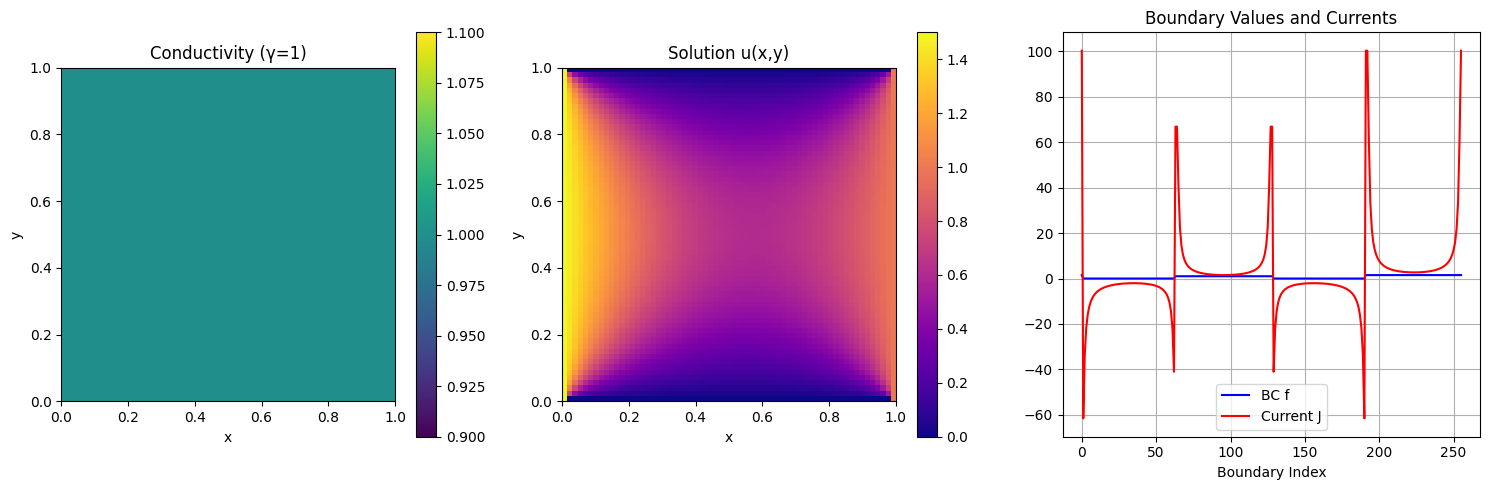

In [8]:
N = 64  # or any other resolution
test_poisson(N, saving_path="poisson_test")

### Analysis

In [41]:
def get_harmonic_bc_n(bnd_coords, n=1):
    """
    Creates boundary conditions for the nth harmonic mode:
    u_n(x,y) = sin(nπx)·cosh(nπ(y-1/2))
    
    Args:
        bnd_coords: Boundary coordinates (num_points, 2)
        n: Mode number (default=1)
    
    Returns:
        Array of boundary values
    """
    x, y = bnd_coords[:, 0], bnd_coords[:, 1]
    bc_values = np.zeros_like(x)
    
    # Identify boundaries
    tol = 1e-12
    bottom_mask = np.abs(y - 0.0) < tol
    top_mask = np.abs(y - 1.0) < tol
    
    # Apply boundary conditions
    bc_values[bottom_mask] = np.sin(n*np.pi*x[bottom_mask]) * np.cosh(n*np.pi/2)
    bc_values[top_mask] = np.sin(n*np.pi*x[top_mask]) * np.cosh(n*np.pi/2)
    
    return bc_values

def get_harmonic_bc_mix(bnd_coords):
    """
    Creates mixed boundary conditions: 0.8·u1 + 0.3·u3
    """
    return 0.8*get_harmonic_bc_n(bnd_coords, n=1) + 0.3*get_harmonic_bc_n(bnd_coords, n=3)

def exact_harmonic_n(x, y, n=1):
    """Returns exact solution for mode n"""
    return np.sin(n*np.pi*x) * np.cosh(n*np.pi*(y-0.5))

def exact_harmonic_mix(x, y):
    """Returns exact solution for mixture"""
    return 0.8*exact_harmonic_n(x, y, n=1) + 0.3*exact_harmonic_n(x, y, n=3)

In [50]:
def test_harmonic_solutions(N, saving_path=None):
    """Test function comparing FDM solutions with exact harmonic solutions."""
    if saving_path is None:
        saving_path = "harmonic_test"
        
    # Create directory if it doesn't exist
    if not os.path.exists(saving_path):
        os.makedirs(saving_path)
    
    # Rest of the function remains the same
    # ...existing code...
    gamma_true = get_gamma_uniform(N)
    
    # Create solver and get boundary info
    solver = FDMForwardSolver(N)
    bnd_info = solver.boundary_info
    bnd_indices = bnd_info['indices']
    bnd_coords = bnd_info['coords']
    
    # Create grid for exact solution
    x = np.linspace(0, 1, N)
    y = np.linspace(0, 1, N)
    X, Y = np.meshgrid(x, y, indexing='ij')
    
    # Test cases: n=1, n=3, and mixture
    cases = [
        (get_harmonic_bc_n, exact_harmonic_n, 1, "n=1"),
        (get_harmonic_bc_n, exact_harmonic_n, 3, "n=3"),
        (get_harmonic_bc_mix, exact_harmonic_mix, None, "mix")
    ]
    
    for bc_func, exact_func, n, label in cases:
        # Get boundary conditions and solve
        if n is not None:
            f_k = bc_func(bnd_coords, n)
            u_exact = exact_func(X, Y, n)
        else:
            f_k = bc_func(bnd_coords)
            u_exact = exact_func(X, Y)
            
        boundary_values = {idx: val for idx, val in zip(bnd_indices, f_k)}
        u_num = solver.solve(gamma_true, boundary_values)
        
        # Compute error
        error = np.abs(u_num - u_exact)
        max_error = np.max(error)
        
        # Plotting
        fig, axes = plt.subplots(1, 3, figsize=(15, 5))
        
        # Plot numerical solution
        im0 = axes[0].imshow(u_num, origin='lower', extent=[0, 1, 0, 1], cmap='plasma')
        axes[0].set_title(f"Numerical Solution ({label})")
        axes[0].set_xlabel("x")
        axes[0].set_ylabel("y")
        fig.colorbar(im0, ax=axes[0])
        
        # Plot exact solution
        im1 = axes[1].imshow(u_exact.T, origin='lower', extent=[0, 1, 0, 1], cmap='plasma')
        axes[1].set_title(f"Exact Solution ({label})")
        axes[1].set_xlabel("x")
        axes[1].set_ylabel("y")
        fig.colorbar(im1, ax=axes[1])
        
        # Plot error
        im2 = axes[2].imshow(error, origin='lower', extent=[0, 1, 0, 1], cmap='viridis')
        axes[2].set_title(f"Error (max={max_error:.2e})")
        axes[2].set_xlabel("x")
        axes[2].set_ylabel("y")
        fig.colorbar(im2, ax=axes[2])
        
        plt.tight_layout()
        plt.savefig(os.path.join(saving_path, f"harmonic_test_{label}.png"), dpi=300)
        plt.show()
        
        # Plot centerline
        plt.figure(figsize=(8, 4))
        plt.plot(x, u_num[:, N//2], 'b-', label='Numerical')
        plt.plot(x, u_exact[:, N//2], 'r--', label='Exact')
        plt.title(f"Centerline Profile (y=0.5) for {label}")
        plt.xlabel("x")
        plt.ylabel("u(x,0.5)")
        plt.legend()
        plt.grid(True)
        plt.savefig(os.path.join(saving_path, f"harmonic_centerline_{label}.png"), dpi=300)
        plt.show()

c:\Users\student\AppData\Local\Programs\Python\Python312\Lib\site-packages\scipy\sparse\_index.py:145: SparseEfficiencyWarning: Changing the sparsity structure of a csc_matrix is expensive. lil_matrix is more efficient.
  self._set_arrayXarray(i, j, x)


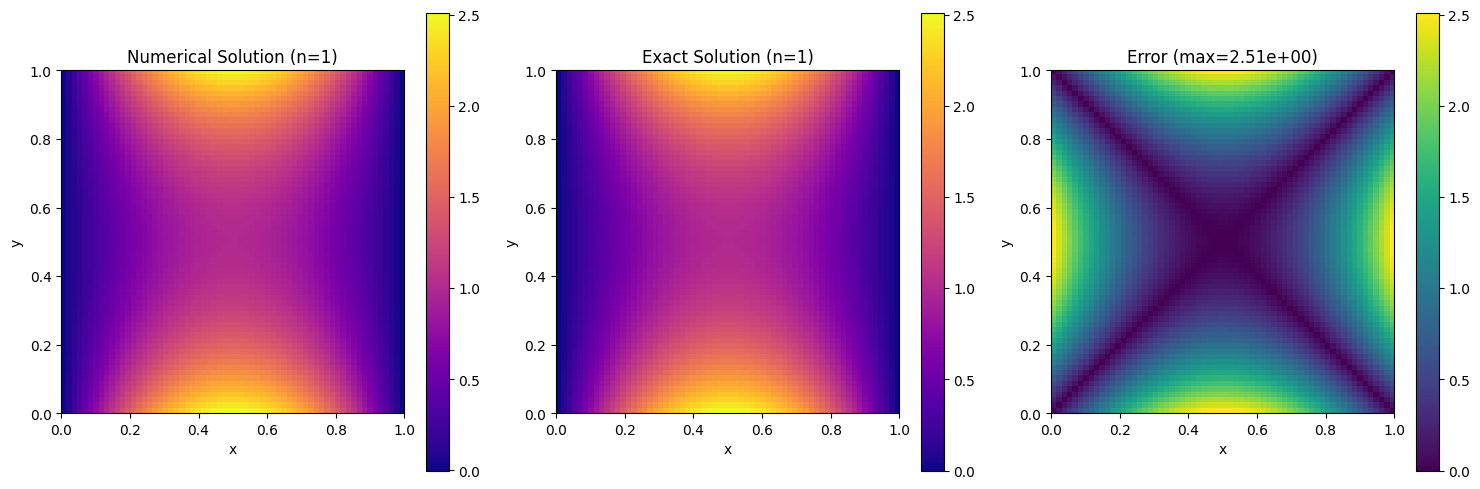

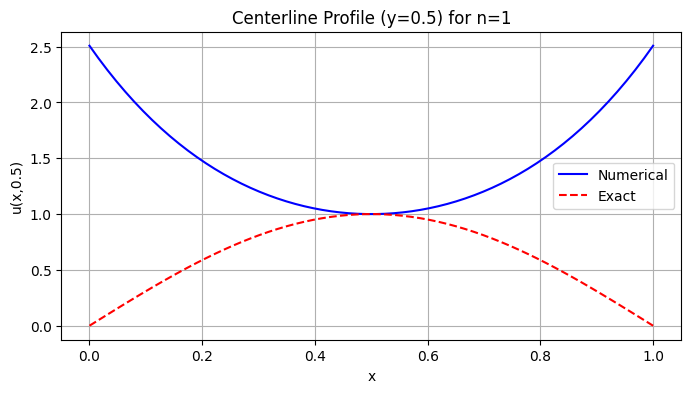

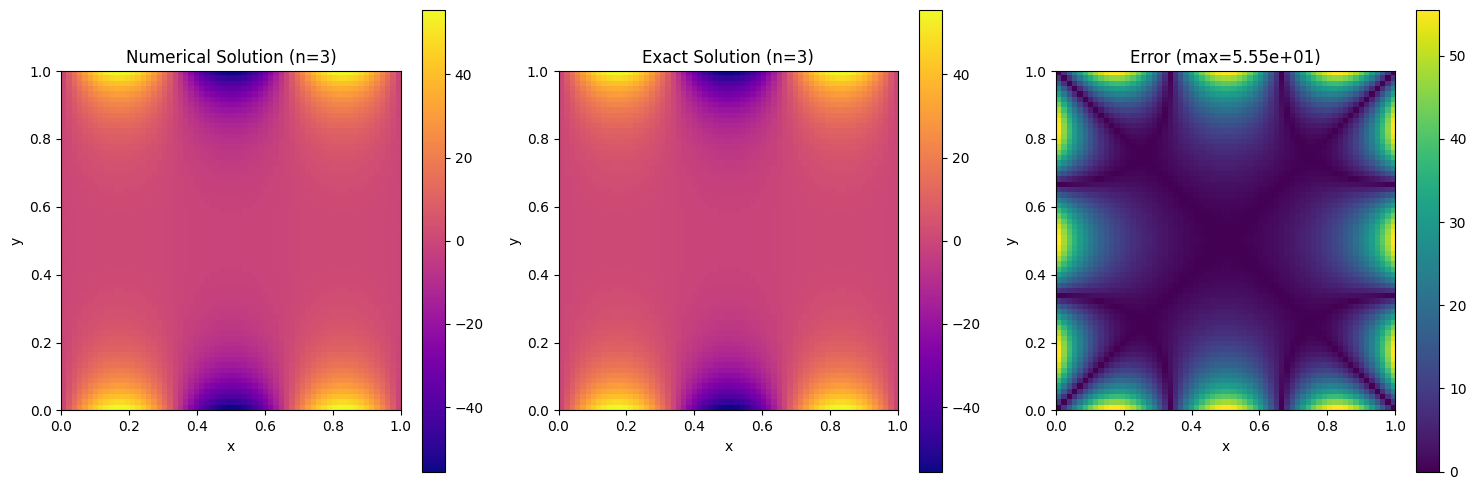

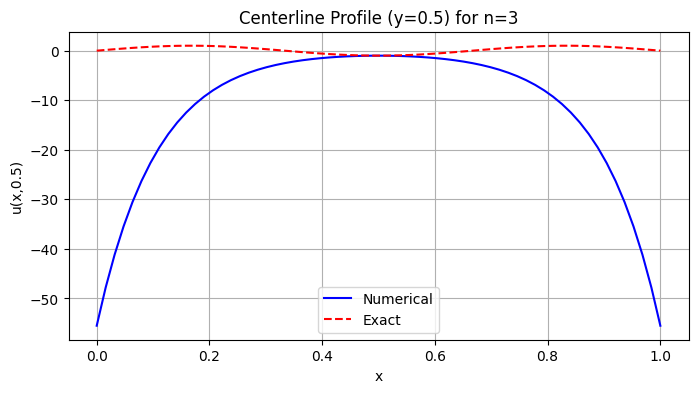

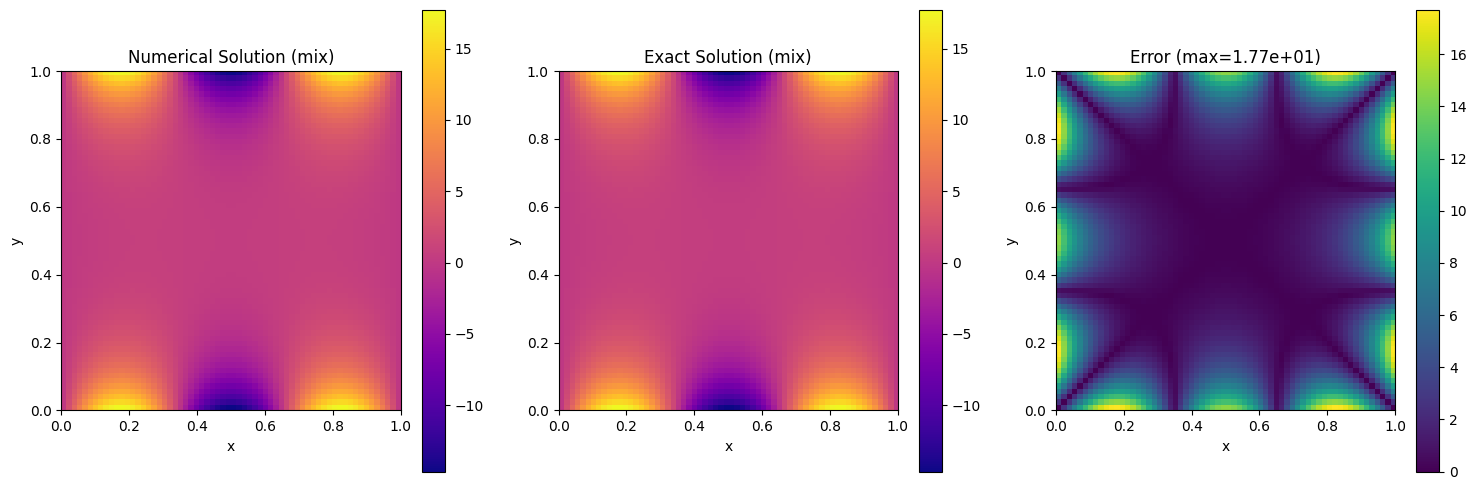

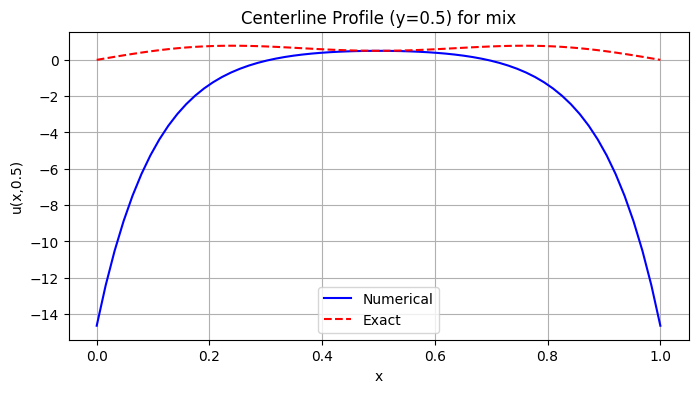

In [51]:
N = 64  # or higher for better resolution
test_harmonic_solutions(N, saving_path="harmonic_test")

### Analysis

In [ ]:
def get_vibrant_wave_bc(bnd_coords, n=1):
    """
    Creates boundary conditions for vibrant middle wave:
    u_n(x,y) = sin(nπx)·cosh(nπ(y-1/2)) satisfying Δu=0
    
    Boundary conditions are:
        u(x,1) = sin(nπx)·cosh(nπ/2)
        u(x,0) = sin(nπx)·cosh(-nπ/2)
        u(0,y) = u(1,y) = 0
    
    Args:
        bnd_coords: Boundary coordinates (num_points, 2)
        n: Wave number (default=1)
    
    Returns:
        Array of boundary values
    """
    x, y = bnd_coords[:, 0], bnd_coords[:, 1]
    bc_values = np.zeros_like(x)
    
    # Identify boundaries
    tol = 1e-12
    top_mask = np.abs(y - 1.0) < tol
    bottom_mask = np.abs(y - 0.0) < tol
    
    # Set top and bottom BCs according to formula
    bc_values[top_mask] = np.sin(n * np.pi * x[top_mask]) * np.cosh(n * np.pi / 2)
    bc_values[bottom_mask] = np.sin(n * np.pi * x[bottom_mask]) * np.cosh(n * np.pi / 2)
    # Left and right boundaries remain 0
    
    return bc_values

def test_vibrant_waves(N, saving_path=None):
    """Tests the vibrant middle wave solutions."""
    if saving_path is None:
        saving_path = "vibrant_wave_test"
    if not os.path.exists(saving_path):
        os.makedirs(saving_path)
        
    # Setup
    gamma = get_gamma_uniform(N)
    solver = FDMForwardSolver(N)
    bnd_coords = solver.boundary_info['coords']
    bnd_indices = solver.boundary_info['indices']
    
    # Test cases
    cases = [
        (1, "Single wave (n=1)"),
        (3, "Triple wave (n=3)"),
    ]
    
    # Also test superposition
    def mixed_bc(coords):
        return 0.8 * get_vibrant_wave_bc(coords, n=1) + 0.3 * get_vibrant_wave_bc(coords, n=3)
    
    for n, title in cases:
        # Get boundary conditions and solve
        f_k = get_vibrant_wave_bc(bnd_coords, n=n)
        boundary_values = {idx: val for idx, val in zip(bnd_indices, f_k)}
        u = solver.solve(gamma, boundary_values)
        
        # Plot solution
        plt.figure(figsize=(10, 8))
        plt.subplot(211)
        plt.imshow(u, origin='lower', extent=[0,1,0,1], aspect='equal', cmap='plasma')
        plt.colorbar(label='u')
        plt.title(f"Solution: {title}")
        plt.xlabel("x")
        plt.ylabel("y")
        
        # Plot centerline
        plt.subplot(212)
        x = np.linspace(0, 1, N)
        plt.plot(x, u[:, N//2], 'b-', label='y=0.5 (centerline)')
        plt.title(f"Centerline wave profile")
        plt.xlabel("x")
        plt.ylabel("u(x,0.5)")
        plt.grid(True)
        
        plt.tight_layout()
        plt.savefig(os.path.join(saving_path, f"wave_n{n}.png"), dpi=300)
        plt.show()
    
    # Test mixture
    f_k = mixed_bc(bnd_coords)
    boundary_values = {idx: val for idx, val in zip(bnd_indices, f_k)}
    u = solver.solve(gamma, boundary_values)
    
    plt.figure(figsize=(10, 8))
    plt.subplot(211)
    plt.imshow(u, origin='lower', extent=[0,1,0,1], aspect='equal', cmap='plasma')
    plt.colorbar(label='u')
    plt.title("Solution: 0.8·u₁ + 0.3·u₃")
    plt.xlabel("x")
    plt.ylabel("y")
    
    plt.subplot(212)
    plt.plot(x, u[:, N//2], 'b-', label='y=0.5 (centerline)')
    plt.title("Centerline wave profile (mixed)")
    plt.xlabel("x")
    plt.ylabel("u(x,0.5)")
    plt.grid(True)
    
    plt.tight_layout()
    plt.savefig(os.path.join(saving_path, "wave_mixed.png"), dpi=300)
    plt.show()

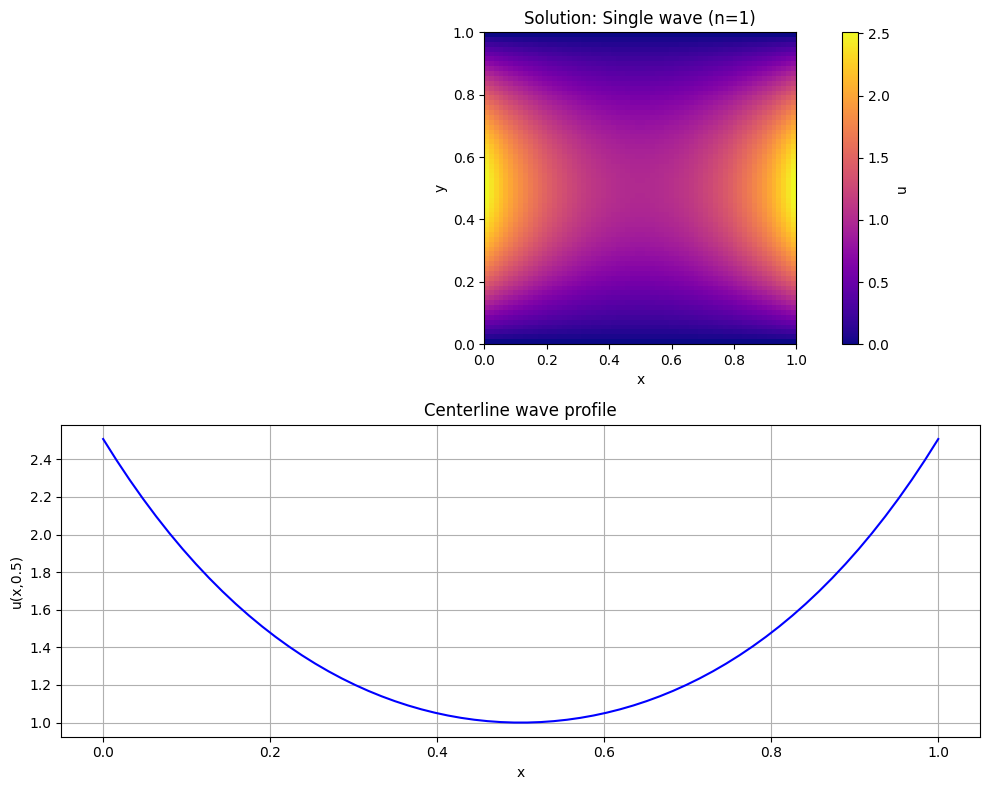

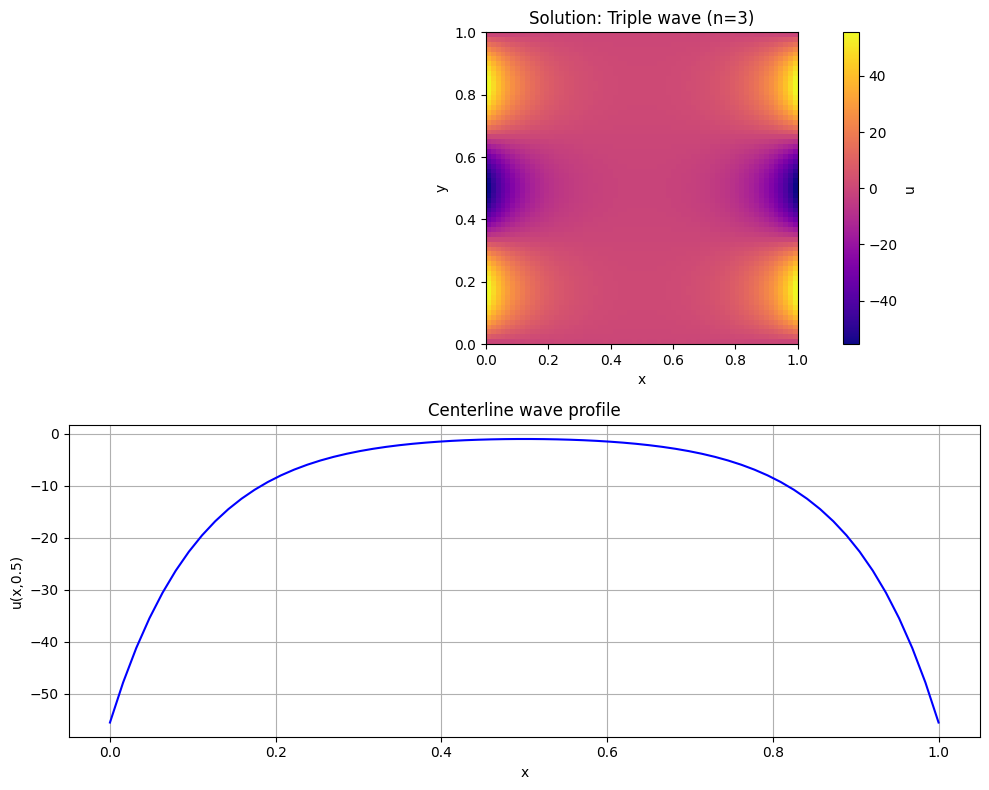

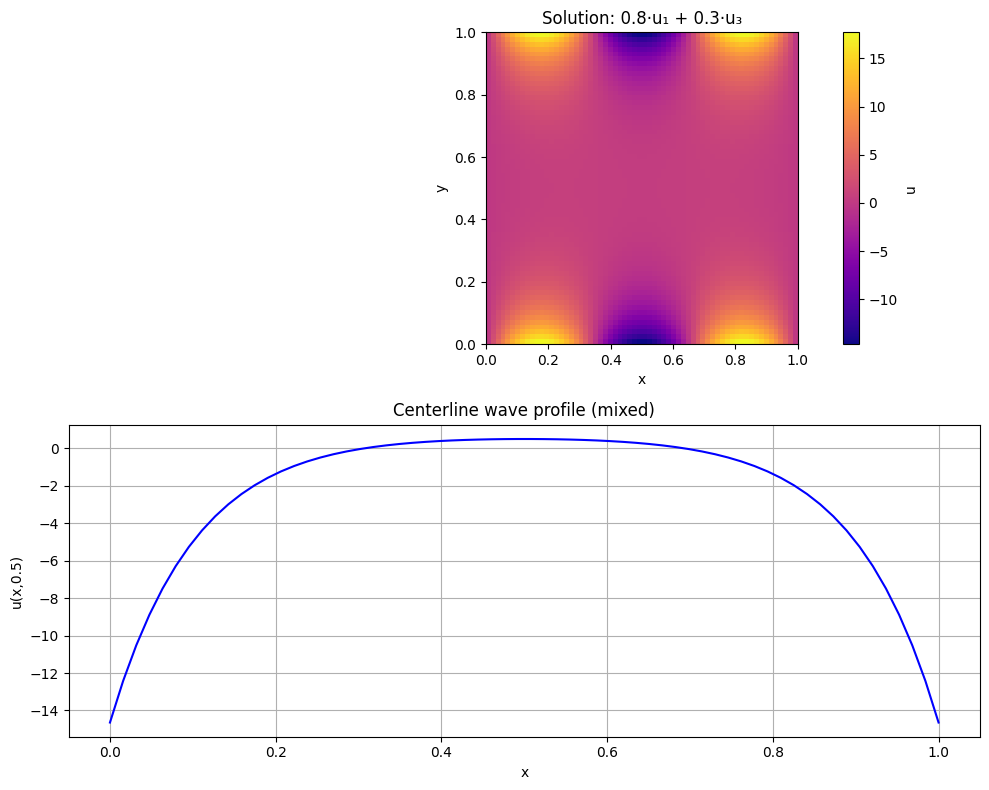

In [47]:
N = 64  # or higher for better resolution
test_vibrant_waves(N, saving_path="vibrant_wave_test")

In [48]:
def get_vibrant_wave_bc(bnd_coords, n=1):
    """
    Creates boundary conditions for vibrant middle wave:
    u_n(x,y) = sin(nπx)·cosh(nπ(y-1/2)) satisfying Δu=0
    
    Boundary conditions are:
        u(x,1) = sin(nπx)·cosh(nπ/2)
        u(x,0) = sin(nπx)·cosh(-nπ/2)
        u(0,y) = u(1,y) = 0
    
    Args:
        bnd_coords: Boundary coordinates (num_points, 2)
        n: Wave number (default=1)
    
    Returns:
        Array of boundary values
    """
    x, y = bnd_coords[:, 0], bnd_coords[:, 1]
    bc_values = np.zeros_like(x)
    
    # Identify boundaries
    tol = 1e-12
    top_mask = np.abs(y - 1.0) < tol
    bottom_mask = np.abs(y - 0.0) < tol
    
    # Set top and bottom BCs according to formula
    bc_values[top_mask] = np.sin(n * np.pi * x[top_mask]) * np.cosh(n * np.pi / 2)
    bc_values[bottom_mask] = np.sin(n * np.pi * x[bottom_mask]) * np.cosh(-n * np.pi / 2)
    # Left and right boundaries remain 0
    
    return bc_values

def test_vibrant_waves(N, saving_path=None):
    """Tests the vibrant middle wave solutions."""
    if saving_path is None:
        saving_path = "vibrant_wave_test"
    if not os.path.exists(saving_path):
        os.makedirs(saving_path)
        
    # Setup
    gamma = get_gamma_uniform(N)
    solver = FDMForwardSolver(N)
    bnd_coords = solver.boundary_info['coords']
    bnd_indices = solver.boundary_info['indices']
    
    # Test cases
    cases = [
        (1, "Single wave (n=1)"),
        (3, "Triple wave (n=3)"),
    ]
    
    # Also test superposition
    def mixed_bc(coords):
        return 0.8 * get_vibrant_wave_bc(coords, n=1) + 0.3 * get_vibrant_wave_bc(coords, n=3)
    
    for n, title in cases:
        # Get boundary conditions and solve
        f_k = get_vibrant_wave_bc(bnd_coords, n=n)
        boundary_values = {idx: val for idx, val in zip(bnd_indices, f_k)}
        u = solver.solve(gamma, boundary_values)
        
        # Create figure with 3 subplots
        plt.figure(figsize=(15, 5))
        
        # Plot 1: Solution
        plt.subplot(131)
        plt.imshow(u, origin='lower', extent=[0,1,0,1], aspect='equal', cmap='plasma')
        plt.colorbar(label='u')
        plt.title(f"Solution: {title}")
        plt.xlabel("x")
        plt.ylabel("y")
        
        # Plot 2: Horizontal centerline u(x,0.5)
        plt.subplot(132)
        x = np.linspace(0, 1, N)
        plt.plot(x, u[:, N//2], 'b-')
        plt.title(f"Horizontal centerline u(x,0.5)")
        plt.xlabel("x")
        plt.ylabel("u(x,0.5)")
        plt.grid(True)
        
        # Plot 3: Vertical centerline u(0.5,y)
        plt.subplot(133)
        y = np.linspace(0, 1, N)
        plt.plot(u[N//2, :], y, 'r-')
        plt.title(f"Vertical centerline u(0.5,y)")
        plt.xlabel("u(0.5,y)")
        plt.ylabel("y")
        plt.grid(True)
        
        plt.tight_layout()
        plt.savefig(os.path.join(saving_path, f"wave_n{n}.png"), dpi=300)
        plt.show()
        
    # Similarly for the mixture case:
    f_k = mixed_bc(bnd_coords)
    boundary_values = {idx: val for idx, val in zip(bnd_indices, f_k)}
    u = solver.solve(gamma, boundary_values)
    
    plt.figure(figsize=(15, 5))
    plt.subplot(131)
    plt.imshow(u, origin='lower', extent=[0,1,0,1], aspect='equal', cmap='plasma')
    plt.colorbar(label='u')
    plt.title("Solution: 0.8·u₁ + 0.3·u₃")
    plt.xlabel("x")
    plt.ylabel("y")
    
    plt.subplot(132)
    plt.plot(x, u[:, N//2], 'b-')
    plt.title("Horizontal centerline u(x,0.5)")
    plt.xlabel("x")
    plt.ylabel("u(x,0.5)")
    plt.grid(True)
    
    plt.subplot(133)
    plt.plot(u[N//2, :], y, 'r-')
    plt.title("Vertical centerline u(0.5,y)")
    plt.xlabel("u(0.5,y)")
    plt.ylabel("y")
    plt.grid(True)
    
    plt.tight_layout()
    plt.savefig(os.path.join(saving_path, "wave_mixed.png"), dpi=300)
    plt.show()

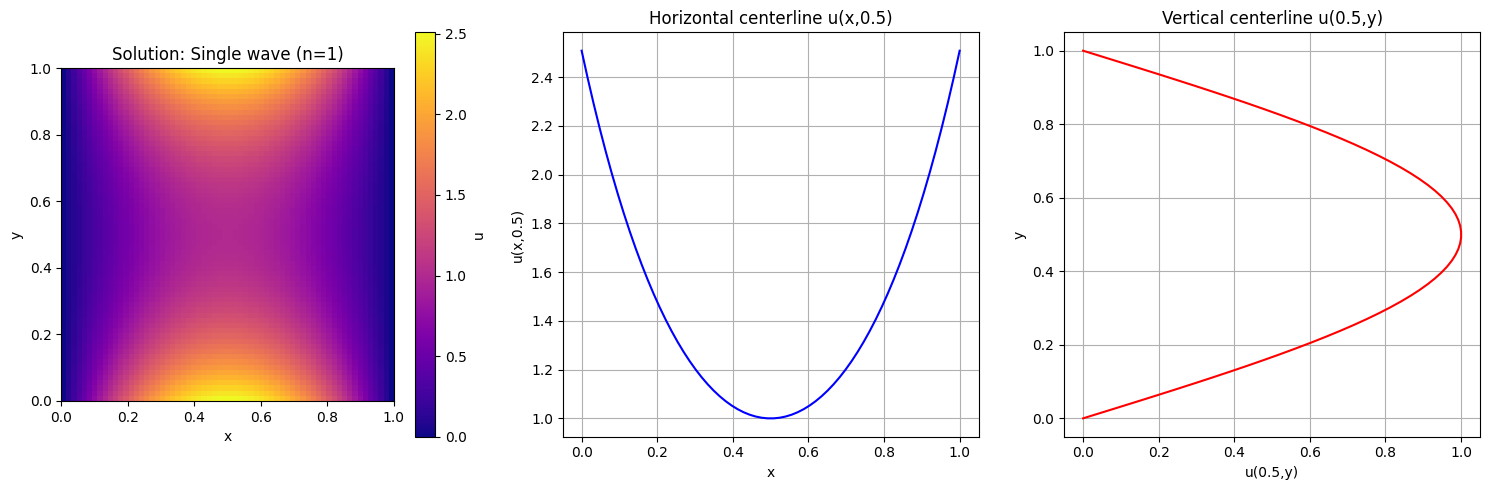

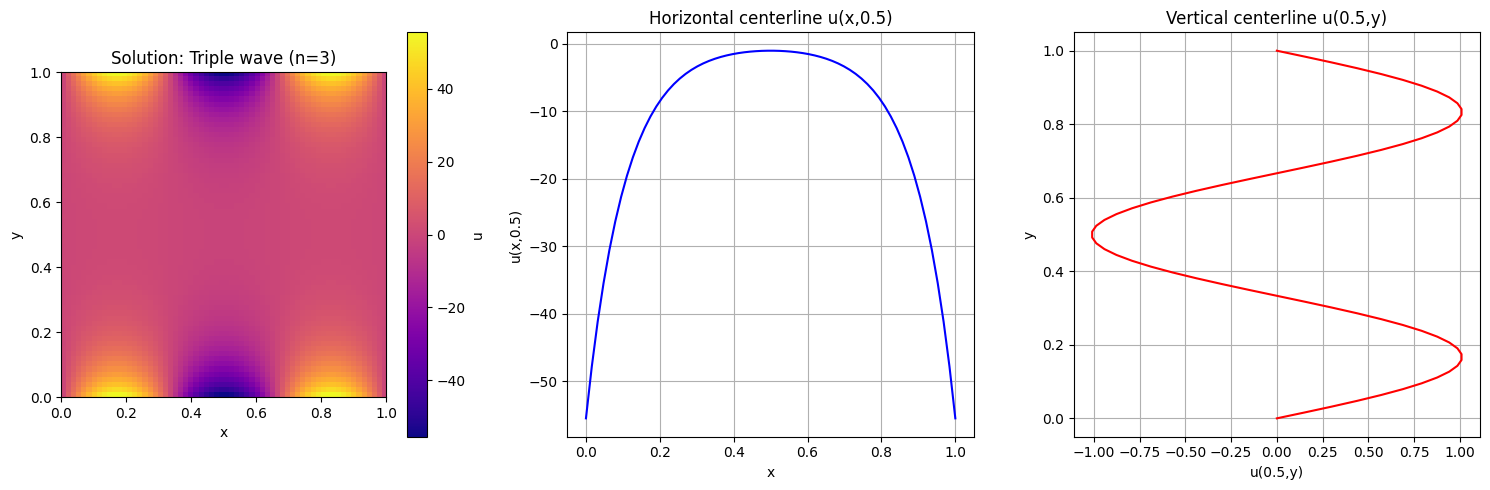

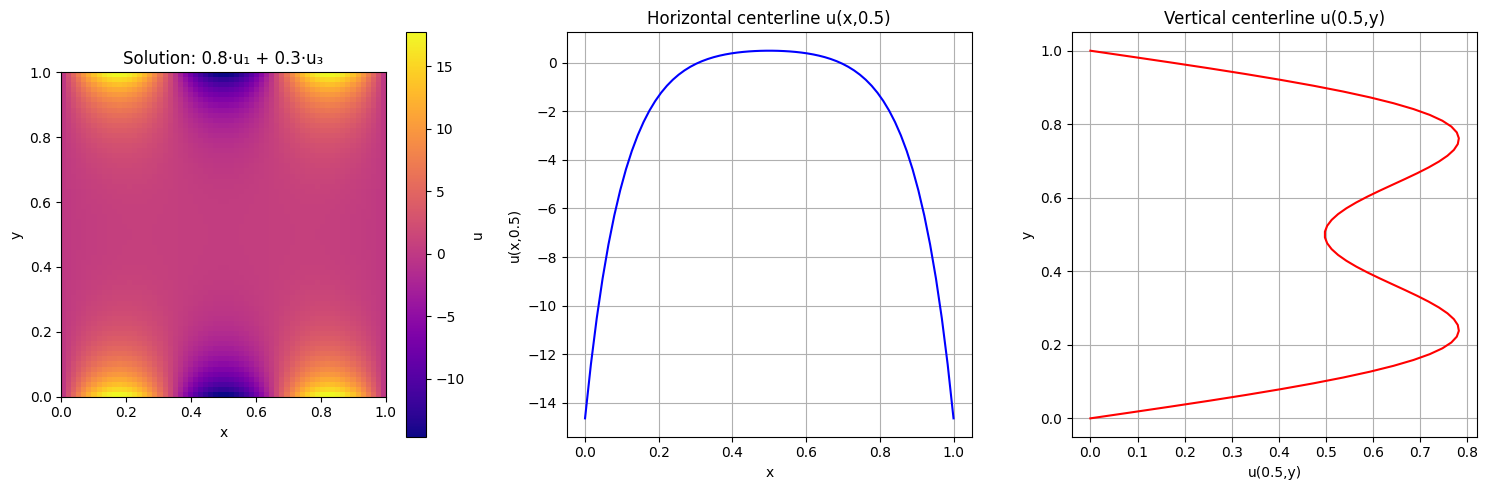

In [49]:
N = 64  # or higher for better resolution
test_vibrant_waves(N, saving_path="vibrant_wave_test")


### Older